In [1]:
%run -i '../../DL Vorlesung/Preamble.py'
import numpy as np
import pandas as pd
import json
from pathlib import Path
import sys
import seaborn as sns
import matplotlib.pyplot as plt
parent_path = Path().resolve().parent.parent  # notebook's parent directory
sys.path.append(str(parent_path))
import util

In [2]:
df = util.load_data('../../data_csv/Data_iaaf_scores_neu.csv')

In [20]:
# 100m-Zeiten
df_100m = df[(df['disziplin'] == "100 m") & (df['geschlecht'] == 'M') & (df['altersklasse'].isin(['Maenner', 'U23', '20']))]['leistung'].dropna().values

# Deutscher Rekord in Sekunden
german_record_time = 9.99  # <--- echten Wert eintragen

NBOOT = 10000
N = len(df_100m)

# Funktion: Bootstrap CI
simulation_100m_m = np.random.choice(df_100m, size = (NBOOT, N), replace = True) # Nboot x N matrix of bootstrap samples

boot_medians = np.median(simulation_100m_m, axis=1)
ci_low = np.percentile(boot_medians, 2.5)
ci_high = np.percentile(boot_medians, 97.5)

# Wahrscheinlichkeit, dass ein Athlet schneller ist als deutscher Rekord
prob_record = np.mean(boot_medians <= german_record_time)  # Achtung: schneller = kleiner

print(f"Bootstrap-Median 100m: {np.median(df_100m):.2f}s")
print(f"95% CI des Medians: [{ci_low:.2f}, {ci_high:.2f}]s")
print(f"Wahrscheinlichkeit, dass ein Athlet den deutschen Rekord erreicht: {prob_record*100:.2f}%")

Bootstrap-Median 100m: 10.66s
95% CI des Medians: [10.65, 10.67]s
Wahrscheinlichkeit, dass ein Athlet den deutschen Rekord erreicht: 0.00%


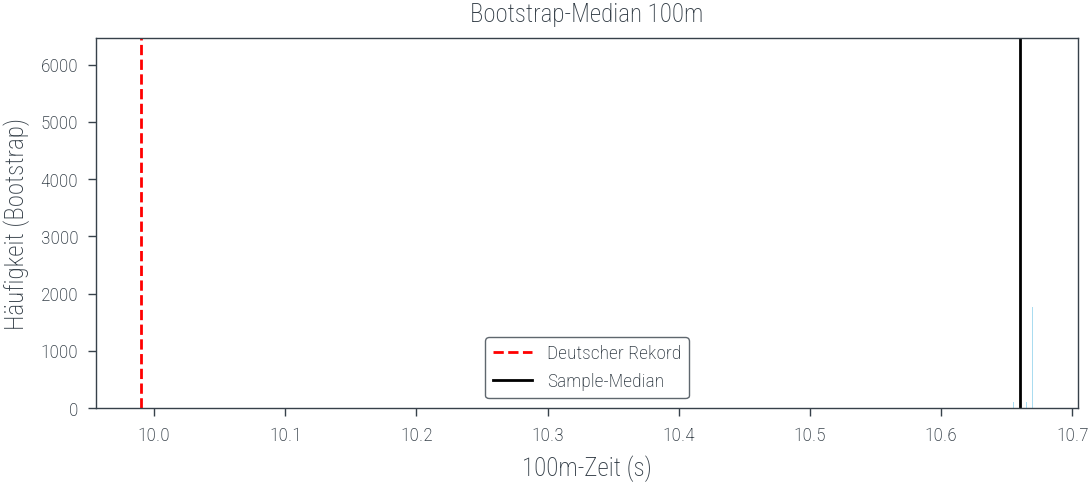

In [14]:
plt.hist(boot_medians, bins=50, alpha=0.7, color='skyblue')
plt.axvline(german_record_time, color='red', linestyle='--', label='Deutscher Rekord')
plt.axvline(np.median(df_100m), color='black', linestyle='-', label='Sample-Median')
plt.xlabel('100m-Zeit (s)')
plt.ylabel('Häufigkeit (Bootstrap)')
plt.title('Bootstrap-Median 100m')
plt.legend()
plt.show()